<a href="https://colab.research.google.com/github/mahativedula/A01-data-wrangling/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing?

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Mahati Vedula

**Date:** 09/02/2026

(30478, 13) 

Host Id                         int64
Host Since                        str
Name                              str
Neighbourhood                     str
Property Type                     str
Review Scores Rating (bin)    float64
Room Type                         str
Zipcode                       float64
Beds                          float64
Number of Records               int64
Number Of Reviews               int64
Price                             str
Review Scores Rating          float64
dtype: object 

Price_NaN
False    30478
Name: count, dtype: int64 

Median price used for missing values: 125.0 

Missing values after cleaning: 0 

(12925, 13) 

response_datetime        str
problem                  str
is_911_call              str
primary_offense          str
subject_injury           str
force_type               str
force_type_action        str
race                     str
sex                      str
age                  float64
type_resistance          str
precinct 

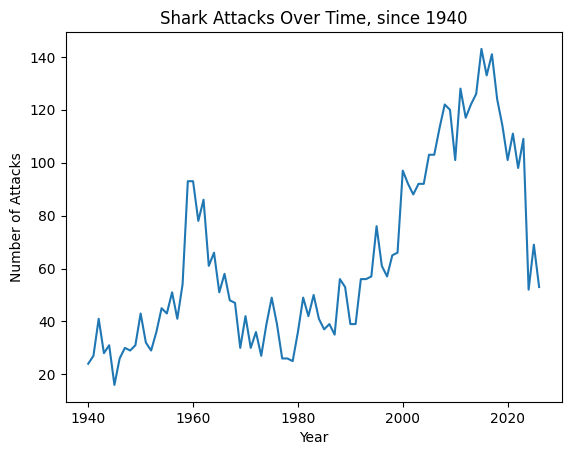

Missing ages: 3169 



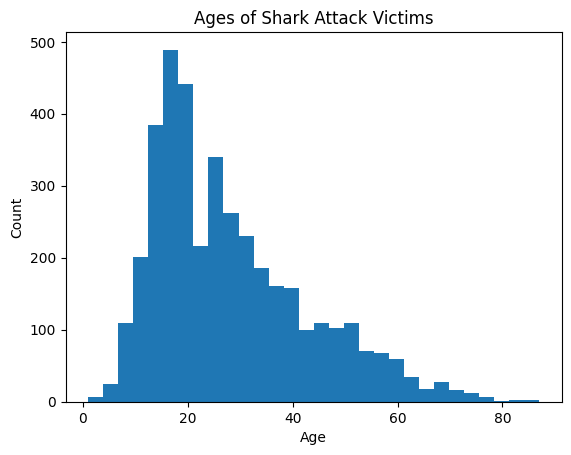

Sex
M      5713
F       818
NaN     586
Name: count, dtype: int64 

Percentage male victims: 87.47511866482928 

Type_Clean
Unprovoked    5263
Unknown       1205
Provoked       649
Name: count, dtype: int64 

Percentage unprovoked attacks: 73.94969790642124 



In [27]:
# Your Phase 1 solution to the problem goes here.

# Imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Airbnb Exploration
airbnb_df = pd.read_csv('data/airbnb_hw.csv', low_memory=False)
print(airbnb_df.shape, '\n')
print(airbnb_df.dtypes, '\n')
airbnb_df.head(n=15)

# AirbnbCleaning

# test: find longest string and print the row
# print("Value of longest string:", airbnb_df['Price'].str.len().idxmax(), '\n')

# 1. Change price type to float, handle commas in the price column
airbnb_df['Price'] = airbnb_df['Price'].str.replace(',', '', regex=False)
airbnb_df['Price'] = pd.to_numeric(airbnb_df['Price'], errors='coerce')

# 2 Create a column to indicate a missing value
airbnb_df['Price_NaN'] = airbnb_df['Price'].isnull()
print(airbnb_df['Price_NaN'].value_counts(), '\n')

# 3. Fill missing values with the median price in a new column
impute_value = airbnb_df['Price'].median()
airbnb_df['Price_Impute'] = airbnb_df['Price'].fillna(impute_value)
print("Median price used for missing values:", impute_value, '\n')
print("Missing values after cleaning:", airbnb_df["Price_Impute"].isnull().sum(), '\n')

# test: check max price after cleaning
# print("Max price after cleaning:", max(airbnb_df['Price_Impute']), '\n')


# Police Exploration

police_df = pd.read_csv('data/mn_police_use_of_force.csv', low_memory=False)
print(police_df.shape, '\n')
print(police_df.dtypes, '\n')
police_df.head(n=15)

print(police_df['subject_injury'].unique(), '\n')
print(police_df['subject_injury'].value_counts(), '\n')

# Police Cleaning

# 1. Quantify the missing values in subject_injury
prop_missing = police_df['subject_injury'].isnull().mean()
print("Proportion missing:", prop_missing*100, '\n')

# 2. Cross tabulate with force_type to assess correlation
print(pd.crosstab(police_df['subject_injury'].isnull(), police_df['force_type']).to_string(), '\n')
print(pd.crosstab(police_df['subject_injury'], police_df['force_type']).to_string(), '\n')


# Shark Exploration
# looked up how to real Excel file, and opened file in Excel for context
shark_df = pd.read_excel('data/GSAF5.xls')
print(shark_df.shape, '\n')
print(shark_df.dtypes, '\n')
shark_df.head(n=15)

# Shark Cleaning
# 1. Remove columns with non-useful data
shark_df = shark_df.drop(columns=['Unnamed: 21', 'Unnamed: 22'])

# 2. Filter data to 1940 and above and create line graph to see trends
shark_df_recent = shark_df[shark_df['Year'] >= 1940]
shark_df_recent['Year'].value_counts().sort_index().plot(kind='line')
plt.xlabel('Year')
plt.ylabel('Number of Attacks')
plt.title('Shark Attacks Over Time, since 1940')
plt.show()

# 3. Clean "Age" variable and make histogram
shark_df['Age'] = pd.to_numeric(shark_df['Age'], errors='coerce')
print("Missing ages:", shark_df['Age'].isnull().sum(), '\n')
plt.hist(shark_df['Age'].dropna(), bins=30)
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Ages of Shark Attack Victims')
plt.show()

# 4. Clean "Sex" variable and find proportion male
shark_df['Sex'] = shark_df['Sex'].str.strip().str.upper()
shark_df['Sex'] = shark_df['Sex'].where(shark_df['Sex'].isin(['M', 'F']), np.nan)
print(shark_df['Sex'].value_counts(dropna=False), '\n')

proportion_male = (shark_df['Sex'] == 'M').sum() / shark_df['Sex'].notnull().sum()
print("Percentage male victims:", proportion_male*100, '\n')

# 5. Clean "Type" variable by grouping into categories
shark_df['Type'] = shark_df['Type'].str.strip().str.upper()
shark_df['Type_Clean'] = np.where(
    shark_df['Type'] == 'PROVOKED', 'Provoked',
    np.where(shark_df['Type'] == 'UNPROVOKED', 'Unprovoked', 'Unknown'))
print(shark_df['Type_Clean'].value_counts(), '\n')

proportion_unprovoked = (shark_df['Type_Clean'] == 'Unprovoked').mean()
print("Percentage unprovoked attacks:", proportion_unprovoked*100, '\n')


Airbnb: The Price column was stored as text, and prices of $1,000 or more included a comma as a thousands separator, which is not valid numeric formatting. Converting the raw column directly with pd.to_numeric caused every comma-containing value to fail parsing and get coerced to NaN. I fixed this by stripping commas with a .str.replace() before the numeric conversion, which correctly preserved these values. After this fix, Price had zero missing values.

Police: The subject_injury variable was already coded cleanly as "Yes" or "No" with genuine missing values, so no reformatting was needed. I found that 76.2% of values were missing, which is a serious concern given it affects the majority of the dataset. To understand why, I cross-tabulated missingness against force_type and found the pattern was not random. Some force types like Less Lethal and Maximal Restraint Technique were missing data 100% of the time, while others like Firearm and Less Lethal Projectile had 0% missingness. This suggests injury outcomes are not missing at random. Reporting likely depends on the type of force used, which could be reflecting inconsistent department reporting requirements across force categories. I left missing values as NaN and treated them as their own category when interpreting the cross-tabulation.

Sharks: I cleaned 4 variables in the shark attack dataset. For Year, I filtered the dataset to 1940 onward, which excludes both the invalid entries and the sparse, less reliable historical records. Plotting attack counts by year shows a long-run increasing trend, along with a recent dip for the most recent years. This likely reflects a mix of rising shark populations/interactions and better data collection in recent decades. Age was stored as text and included non-numeric placeholders like "?", "20's", and "30+"; I used pd.to_numeric() to convert valid numeric ages and drop the rest as missing, which is the same approach used for Price in Airbnb. Sex had inconsistent formatting (extra whitespace, lowercase "m") and invalid entries ("N", ".", "M x 2"). After standardizing case and whitespace, I treated anything other than "M" or "F" as missing, and computed the proportion male only among records with a known sex. Finally, Type had many overlapping labels. I standardized case/whitespace to consolidate the true Provoked/Unprovoked labels and collapsed every other category into "Unknown", since categories like "Questionable" or "Boat" don't unambiguously indicate provocation status.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [28]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]